From https://github.com/langchain-ai/langgraph/blob/main/docs/docs/tutorials/lats/lats.ipynb


## Agent LATS

In [ ]:
# Import required libraries for LATS (Language Agent Tree Search) implementation
import os
import pandas as pd
import textwrap
import logging
from termcolor import colored  # For colored terminal output
from langgraph.prebuilt import ToolNode  # Pre-built tool execution node
from dotenv import load_dotenv  # Environment variable loading
from typing import TypedDict
from langchain_ollama import ChatOllama  # Local LLM integration

# Enable debug mode for detailed logging
DEBUG=True

### Logging

In [9]:
def setup_logger(debug=True):
    """Setup logger with proper formatting and level."""
    logger = logging.getLogger("my-logger")
    logger.setLevel(logging.DEBUG if debug else logging.INFO)
    
    if not logger.hasHandlers():
        console_handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        console_handler.setFormatter(formatter)
        logger.addHandler(console_handler)
    
    return logger

logger = setup_logger(DEBUG)

In [10]:
def prettyprint(obj, color='white'):
    """Pretty print messages with proper error handling and type checking."""
    try:
        wrapper = textwrap.TextWrapper(width=80)
        
        if isinstance(obj, list):
            text = obj[-1]
            logger.debug(f"### Message {len(obj) - 1} ###")
            content = getattr(text, 'content', str(text))
            wrapped_text = wrapper.wrap(str(content))
            logger.debug(colored("\n".join(wrapped_text), color=color))
        else:
            content = getattr(obj, 'content', str(obj))
            wrapped_text = wrapper.wrap(str(content))
            logger.debug(colored("\n".join(wrapped_text), color=color))
    except Exception as e:
        logger.error(f"Error in prettyprint: {str(e)}")

In [11]:
def pprint(obj, color='white'):
    wrapper = textwrap.TextWrapper(width=82)
    wrapped_text = wrapper.wrap(str(obj))
    print(colored("\n".join(wrapped_text), color=color))

In [12]:
class Config:
    """Central configuration management."""
    def __init__(self):
        self.DEBUG = True
        self.EXPLORATION_WEIGHT = 1.0
        self.MAX_TREE_HEIGHT = 5
        self.NUM_CANDIDATES = 2
        self.BUDGET = 1000
        self.ALPHA = 0.5
        
config = Config()

### Instantiate LLM

In [13]:
llm = ChatOllama(model = "qwen3:32b", temperature=0.0, top_k=2, top_p=0.9, verbose=True)

In [14]:
llm.invoke('what is 2 + 2?')

AIMessage(content='<think>\nOkay, so the user is asking "what is 2 + 2?" Hmm, that seems straightforward, but maybe I should think through it carefully. Let me start by recalling basic arithmetic. Addition is one of the fundamental operations in mathematics. When you add two numbers, you\'re combining their values. So 2 plus 2... Well, 2 is a whole number, and adding another 2 would mean moving two steps forward from 2 on the number line. Let me visualize that: starting at 2, adding 1 gets me to 3, and adding another 1 gets me to 4. So that would make 2 + 2 equal to 4.\n\nWait, but maybe I should consider different number systems? For example, in binary, 2 is represented as 10. If I add 10 + 10 in binary, that would be 100, which is 4 in decimal. So even in binary, it still comes out to 4. What about modulo arithmetic? If we\'re working modulo 3, then 2 + 2 would be 1, because 4 divided by 3 leaves a remainder of 1. But the question doesn\'t specify a modulus, so I think the default is

### Load parameters

In [15]:
# Load .env file
load_dotenv()
api_key = os.getenv("BRAVE_API_KEY")

In [16]:
import os

def _set_env(var: str) -> None:
    if not os.environ.get(var):
        load_dotenv()
        os.environ[var] = os.getenv(var)

os.environ["LANGSMITH_TRACING"] = "true"
_set_env("LANGSMITH_API_KEY")

### Instantiate Search Tool 

In [17]:
from langchain_community.tools import BraveSearch
search_tool = BraveSearch.from_api_key(api_key=api_key, search_kwargs={"count": 1})
tools = [search_tool]
tool_node = ToolNode(tools=tools)

### Reflection Class

In [18]:
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage

class Reflection(BaseModel):
    reflection: str = Field(
        description="The critique and reflections on the sufficiency, superfluency,"
        " and general quality of the response"
    )
    score: int = Field(
        description="Score from 0-100 on the quality of the candidate response."
    )
    found_solution: bool = Field(
        description="Whether the response has fully solved the question or task."
    )

    def as_message(self):
        return HumanMessage(content=f"Reflection: {self.reflection}\nScore: {self.score}")

    @property
    def normalized_score(self) -> float:
        return self.score / 100.0

In [19]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import chain as as_runnable

from langchain_core.runnables import chain as as_runnable
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Reflect and grade the assistant response (candidate) to the user question (question)."
         "Be thorough and do not accept incomplete reposnses. Ask for improvement if the answer is not complete."
         "The score must be an integer number between 0 and 100. " 
         ),
        ("user", "{question}"),
        ("ai", "{candidate}"),
        #("ai", "{data}")
    ]
)

model = llm.with_structured_output(Reflection)
reflection_chain = prompt | model


In [20]:
from langchain_core.messages import BaseMessage
import math

class Node:
    def __init__(self, messages, response, reflection: Reflection, parent=None):
        self.messages = messages
        self.parent = parent
        self.children = []
        self.reflection = reflection
        self.response = response
        self.value = 0
        self.visits = 0
        self._is_solved = (reflection.found_solution and reflection.score > 5)
        if self._is_solved:
            self._mark_tree_as_solved()

    @property
    def is_solved(self):
        """If any solutions exist, we can end the search."""
        return self._is_solved

    @property
    def height(self) -> int:
        """Check for how far we've rolled out the tree."""
        if self.children:
            return 1 + max([child.height for child in self.children])
        return 1

    def upper_confidence_bound(self, exploration_weight=1.0):
        if self.parent is None:
            raise ValueError
        if self.visits == 0:
            return self.value
        average_reward = self.value / self.visits
        exploration_term = math.sqrt(math.log(self.parent.visits) / self.visits)
        return average_reward + exploration_weight * exploration_term

    def get_messages(self, include_reflections: bool = True):
        if include_reflections:
            return self.messages + [self.reflection.as_message()]
        return self.messages

    def get_trajectory(self, include_reflections: bool = True) -> list[BaseMessage]:
        """Get messages representing this search branch."""
        messages = []
        node = self
        while node:
            messages.extend(
                node.get_messages(include_reflections=include_reflections)[::-1]
            )
            node = node.parent
        # Reverse the final back-tracked trajectory to return in the correct order
        return messages[::-1]  # root solution, reflection, child 1, ...

    def _mark_tree_as_solved(self):
        parent = self.parent
        while parent:
            parent._is_solved = True
            parent = parent.parent

In [21]:
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from typing import Annotated

class TreeState(TypedDict):
    root: Node
    input: str
    response: str
    final_response: str
    messages: Annotated[list, add_messages]

In [22]:
llm.bind_tools(tools=tools)

RunnableBinding(bound=ChatOllama(model='qwen3:32b', temperature=0.0, top_k=2, top_p=0.9), kwargs={'tools': [{'type': 'function', 'function': {'name': 'brave_search', 'description': 'a search engine. useful for when you need to answer questions about current events. input should be a search query.', 'parameters': {'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}]}, config={}, config_factories=[])

In [23]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are an AI assistant."
        " Generate a response for the input question based on messages"
        " If asked to generate a report, generate it using formal language. Do not make unnecessary comments."),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="messages", optional=True),
    ]
)

initial_answer_chain = prompt_template | llm.bind_tools(tools=tools)#.with_config(run_name="GenerateInitialCandidate")

In [24]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage

def generate_initial_response(state: TreeState):
    """Generate the initial candidate response"""
    pprint("---- Generate Initial Response ----")
    query = state["input"]
    ai_msg = initial_answer_chain.invoke({"input": query})
    messages = [ai_msg.content]

    parsed = []
    for tool_call in ai_msg.tool_calls:
        d = {}
        d['name'] = tool_call['name']
        d['args'] = tool_call['args']
        d['id'] = tool_call['id']
        parsed.append(d)

    for r in parsed:
        tool_msg = tool_node.invoke(
            {
                "messages": [
                    AIMessage(
                        content="",
                        tool_calls=[
                            {"name": r["name"], "args": r["args"], "id": r["id"]}
                        ],
                    )
                ]
            }
        )
        messages.extend(tool_msg['messages'])

    response = initial_answer_chain.invoke(messages)
    pprint('### Initial Response ###')
    pprint(response)
    messages.append(response)
    reflection = reflection_chain.invoke({"question": query, "candidate": messages})
    pprint('\n\n') 
    pprint('### Reflection ###')
    pprint(reflection, color="green")
    state['messages'] = messages
    root = Node(messages, response=response, reflection=reflection)
    state['response'] = response

    return {
        **state,
        "root": root,
    }

In [25]:
initial_response = generate_initial_response({"input": "Write a research report on lithium pollution."})

---- Generate Initial Response ----
### Initial Response ###
content='<think>\nOkay, the user asked for a research report on lithium pollution.
I need to structure this properly. Let me start by looking at the tool response
they provided. The search results mention several key points: lithium\'s
distribution in the environment, its impact on ecosystems, studies on soybean
development, and risk management strategies. There\'s also a mention of
contamination from mining to mobiles.\n\nFirst, the introduction should highlight
the importance of lithium in modern technology and the emerging environmental
concerns. Then, sources of pollution—mining, battery production, disposal. The
tool response points to mining activities and electronic industry proliferation as
main sources. \n\nNext, environmental impact. The PMC article talks about effects
on plants, animals, and humans. The soybean study shows metabolic changes, which
indicates soil contamination. Aquatic ecosystems might be affected t

In [26]:
for i, msg in enumerate(initial_response['messages']):
    print(f'---Message {i}---') 
    pprint(msg)

---Message 0---
<think> Okay, the user wants a research report on lithium pollution. Let me start
by understanding what exactly they need. A research report should be formal and
structured, so I need to make sure I cover all the necessary sections like
introduction, sources, environmental impact, case studies, mitigation strategies,
and a conclusion.  First, I need to gather current information on lithium
pollution. Since lithium is widely used in batteries, especially with the rise of
electric vehicles and renewable energy storage, pollution from lithium might be a
growing concern. But I'm not entirely sure about the latest data, so I should use
the brave_search function to find recent studies or reports.  I should start by
searching for "lithium pollution sources and environmental impact 2023" to get up-
to-date information. That should help me outline the main sources of lithium
pollution, such as mining activities, battery production, and improper disposal of
lithium-ion batteries.

In [27]:
initial_response['root'].response

AIMessage(content='<think>\nOkay, the user asked for a research report on lithium pollution. I need to structure this properly. Let me start by looking at the tool response they provided. The search results mention several key points: lithium\'s distribution in the environment, its impact on ecosystems, studies on soybean development, and risk management strategies. There\'s also a mention of contamination from mining to mobiles.\n\nFirst, the introduction should highlight the importance of lithium in modern technology and the emerging environmental concerns. Then, sources of pollution—mining, battery production, disposal. The tool response points to mining activities and electronic industry proliferation as main sources. \n\nNext, environmental impact. The PMC article talks about effects on plants, animals, and humans. The soybean study shows metabolic changes, which indicates soil contamination. Aquatic ecosystems might be affected too, though the tool response doesn\'t specify, but 

In [28]:
initial_response['root'].messages

['<think>\nOkay, the user wants a research report on lithium pollution. Let me start by understanding what exactly they need. A research report should be formal and structured, so I need to make sure I cover all the necessary sections like introduction, sources, environmental impact, case studies, mitigation strategies, and a conclusion.\n\nFirst, I need to gather current information on lithium pollution. Since lithium is widely used in batteries, especially with the rise of electric vehicles and renewable energy storage, pollution from lithium might be a growing concern. But I\'m not entirely sure about the latest data, so I should use the brave_search function to find recent studies or reports.\n\nI should start by searching for "lithium pollution sources and environmental impact 2023" to get up-to-date information. That should help me outline the main sources of lithium pollution, such as mining activities, battery production, and improper disposal of lithium-ion batteries. Also, lo

In [29]:
prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are an AI assistant."
        " Generate a response for the input question expanding on the messages and tool calls generated by the previous assistant"
        " Generate some variability in your search queries. "
        " Call the tool again to further reasearch for your response."
        " If asked to generate a report, generate it using formal language. Do not make unnecessary comments."),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="messages", optional=True),
    ]
)

expansion_chain = prompt_template | llm.bind_tools(tools=tools)

In [30]:
prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are an AI assistant."
        " Generate a response for the input question based on messages generated by the previous agent. "
        " Expand on the answer give by the previous agent. "
        " If asked to generate a report, generate it using formal language. Do not make unnecessary comments."),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="messages", optional=True),
    ]
)

response_chain = prompt_template | llm

In [31]:
from typing_extensions import List

def generate_candidates(state: TreeState) -> List[List[BaseMessage]]:
    """Generate candidate responses with proper error handling."""
    try:
        all_messages = []
        query = state['input']
        messages = state['messages'].copy()  # Make a copy to avoid modifying original
        
        for i in range(config.NUM_CANDIDATES):
            logger.debug(f'Generating candidate {i+1}/{config.NUM_CANDIDATES}')
            ai_msg = expansion_chain.invoke({"input": query})
            messages.append(ai_msg.content)
            
            try:
                parsed = [
                    {
                        'name': tool_call['name'],
                        'args': tool_call['args'],
                        'id': tool_call['id']
                    }
                    for tool_call in ai_msg.tool_calls
                ]
                
                for r in parsed:
                    tool_msg = tool_node.invoke({
                        "messages": [AIMessage(
                            content="",
                            tool_calls=[r]
                        )]
                    })
                    messages.extend(tool_msg['messages'])
                    
                response = response_chain.invoke({'input': query, 'messages': messages})
                messages.append(response)
                all_messages.append(messages)
                
            except Exception as e:
                logger.error(f"Error processing candidate {i}: {str(e)}")
                continue
                
        return all_messages
        
    except Exception as e:
        logger.error(f"Fatal error in generate_candidates: {str(e)}")
        return []

In [32]:
res = generate_candidates(initial_response)

2025-08-10 21:33:41,010 - DEBUG - Generating candidate 1/2
2025-08-10 21:35:35,502 - DEBUG - Generating candidate 2/2


In [33]:
len(res)

2

In [34]:
for msg in res[0]:
    prettyprint(msg)

2025-08-10 21:37:38,981 - DEBUG - <think> Okay, the user wants a research report on lithium pollution. Let me
start by understanding what exactly they need. A research report should be
formal and structured, so I need to make sure I cover all the necessary sections
like introduction, sources, environmental impact, case studies, mitigation
strategies, and a conclusion.  First, I need to gather current information on
lithium pollution. Since lithium is widely used in batteries, especially with
the rise of electric vehicles and renewable energy storage, pollution from
lithium might be a growing concern. But I'm not entirely sure about the latest
data, so I should use the brave_search function to find recent studies or
reports.  I should start by searching for "lithium pollution sources and
environmental impact 2023" to get up-to-date information. That should help me
outline the main sources of lithium pollution, such as mining activities,
battery production, and improper disposal of lithi

In [35]:
def select(root: Node) -> dict:
    """Starting from the root node a child node is selected at each tree level until a leaf node is reached."""

    print('--- SELECT ---')
    if not root.children:
        print('not children')
        return root

    node = root
    while node.children:
        print(f'children: {node.children}')
        max_child = max(node.children, key=lambda child: child.upper_confidence_bound())
        print('### Max Child ###')
        print(max_child)
        node = max_child

    return node

In [36]:
from langchain_core.runnables import RunnableConfig
from collections import defaultdict
import textwrap

def expand(state: TreeState):
    """Starting from the best node in the tree, generate N candidates for the next step"""
    root = state["root"]
    best_candidate = select(root)
    messages = best_candidate.get_trajectory(True)

    print('---State Input---')
    print('Question')
    pprint(state['input'])

    new_candidates = generate_candidates(
        {"input": state["input"], "messages": messages}
    )

    child_nodes = []
    for c in new_candidates:
        print("--- Candidate ---")
        # prettyprint(c[1][1])
        response = c[-1]
        reflection = reflection_chain.invoke({"question": state['input'],
                                             "candidate": c})
        
        print('---Response--')
        pprint(response)
        print('\n\n')

        print('---Reflection---')
        pprint(reflection)
        child_nodes.append(
            Node(c, response=response, parent=best_candidate, reflection=reflection)
        )
    best_candidate.children.extend(child_nodes)

    return state


In [37]:
res = expand(initial_response)

2025-08-10 21:37:38,999 - DEBUG - Generating candidate 1/2


--- SELECT ---
not children
---State Input---
Question
Write a research report on lithium pollution.


2025-08-10 21:39:22,143 - DEBUG - Generating candidate 2/2


--- Candidate ---
---Response--
content='<think>\nOkay, the user wants a research report on lithium pollution. Let
me start by understanding what exactly they need. A research report should be
formal, structured, and include key sections like introduction, sources of
pollution, environmental impact, health effects, mitigation strategies, and a
conclusion.\n\nFirst, I need to gather information on lithium pollution. I
remember that lithium is used in batteries, especially for electric vehicles and
electronics. But how does it become pollution? Maybe from mining processes,
battery production waste, or improper disposal of lithium-ion batteries. I should
check recent studies or articles on this.\n\nI\'ll use the brave_search tool to
find relevant information. Let me start with a general search on lithium pollution
sources. The query could be "lithium pollution sources and environmental impact".
That should give an overview. Then, I might need more specific data on health
effects, so anoth

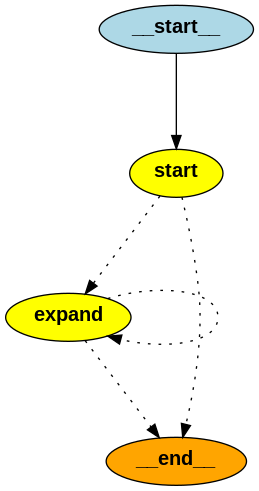

In [38]:
from typing import Literal
from langgraph.graph import END, StateGraph, START
from IPython.display import Image


def should_loop(state: TreeState):
    """Determine whether to continue the tree search."""
    root = state["root"]
    if root.is_solved or root.height > 5:
        state['final_response'] = root.get_trajectory()[-1]
        return END
    return "expand"


builder = StateGraph(TreeState)
builder.add_node("start", generate_initial_response)
builder.add_node("expand", expand)
builder.add_edge(START, "start")


builder.add_conditional_edges(
    "start",
    # Either expand/rollout or finish
    should_loop,
    ["expand", END],
)
builder.add_conditional_edges(
    "expand",
    # Either continue to rollout or finish
    should_loop,
    ["expand", END],
)

graph = builder.compile()
Image(graph.get_graph().draw_png())

In [39]:
question = "Write an essay about Lithium pollution"
response = graph.invoke({"input": question})

---- Generate Initial Response ----
### Initial Response ###
content="<think>\nOkay, the user asked for an essay on lithium pollution. I need
to start by understanding the key points from the provided tool response. The
search result mentions environmental impacts like water usage, pollution, CO2
emissions, mineral waste, respiratory issues, and hydrological cycle alterations.
The article from Columbia University's State of the Planet highlights the paradox
of lithium being essential for clean energy but having negative mining
impacts.\n\nFirst, I should structure the essay with an introduction about
lithium's role in modern tech. Then discuss extraction methods, environmental
impacts, case studies (like Atacama Desert), and solutions. The tool response
mentions specific issues like water consumption in brine extraction and pollution
from processing chemicals. Also, the need for strict regulations and advanced
methods like seawater extraction.\n\nI need to ensure the essay is formal an